# RQ1. ¿El mayor riesgo se compensa con mayor retorno ajustado?

## Pregunta e hipótesis

**Pregunta.** Entre los sectores del S&P 500, ¿asumir más volatilidad compra mejor
retorno ajustado por riesgo?

**H1 (formulada a priori, registrada en la spec del proyecto):** entre sectores, la
volatilidad histórica NO predice mayor retorno ajustado por riesgo (Sharpe). Si la
relación existiera y fuera positiva, cargar la cartera hacia sectores volátiles
sería gratis; la hipótesis afirma que no lo es.

## Método

1. Retornos mensuales de los 9 ETFs sectoriales SPDR (todos listados en dic 1998:
   sin sesgo de cobertura, ver RQ0) desde `v_monthly_returns`.
2. Por sector: retorno anualizado, volatilidad anualizada, Sharpe y Sortino; máximo
   drawdown desde precios diarios.
3. Incertidumbre: IC 95% del Sharpe por bootstrap en bloques circular (bloque de
   6 meses, 1000 remuestreos, semilla fija 42).
4. Contraste de H1: correlación de rangos de Spearman entre volatilidad y Sharpe
   sectorial. Spearman y no Pearson: 9 observaciones, sin supuesto de linealidad.
5. Robustez: subperiodos 1999-2008, 2009-2026, pre-2020 y 2020-2026.

In [1]:
import sys
from pathlib import Path

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from src import metrics
from src.db import get_engine

eng = get_engine()
SECTORS = ["XLK", "XLF", "XLE", "XLV", "XLI", "XLP", "XLY", "XLU", "XLB"]
SECTOR_NAMES = pd.read_sql(
    "SELECT ticker, sector FROM dim_asset", eng).set_index("ticker")["sector"]

monthly = pd.read_sql(
    "SELECT ticker, month_end, monthly_ret FROM v_monthly_returns", eng)
wide = monthly.pivot(index="month_end", columns="ticker", values="monthly_ret")
wide.index = pd.to_datetime(wide.index)
sec = wide[SECTORS].dropna()
print(f"Muestra sectorial: {sec.index.min().date()} a {sec.index.max().date()}, {len(sec)} meses")

Muestra sectorial: 1999-01-29 a 2026-07-10, 331 meses


## Resultados

### Tabla maestra del universo completo

Contexto general antes del contraste sectorial. Métricas sobre la historia
completa de cada activo (inicios distintos: comparar con cautela, ver RQ0).

In [2]:
daily_prices = metrics.get_prices()
rows = []
for tk in daily_prices.columns:
    p = daily_prices[tk].dropna()
    r = p.pct_change()
    rows.append({
        "ticker": tk,
        "inicio": p.index.min().strftime("%Y-%m"),
        "ret_anual": metrics.annualized_return(p),
        "vol_anual": metrics.annualized_vol(r),
        "sharpe": metrics.sharpe(r),
        "sortino": metrics.sortino(r),
        "max_drawdown": metrics.max_drawdown(p),
    })
master = pd.DataFrame(rows).set_index("ticker").sort_values("sharpe", ascending=False)
master.round(3)

,inicio,ret_anual,vol_anual,sharpe,sortino,max_drawdown
ticker,,,,,,
SHY,2002-07,0.020,0.015,1.300,1.821,-0.057
VOO,2010-09,0.150,0.170,0.906,1.112,-0.340
MSFT,1986-03,0.243,0.332,0.823,1.153,-0.694
JNJ,1962-01,0.139,0.228,0.684,0.998,-0.507
SPY,1993-01,0.109,0.186,0.648,0.828,-0.552
GLD,2004-11,0.104,0.182,0.636,0.845,-0.456
AAPL,1980-12,0.194,0.437,0.628,0.863,-0.818
XOM,1962-01,0.121,0.230,0.612,0.868,-0.624
AGG,2003-09,0.031,0.052,0.612,0.745,-0.184


### Métricas sectoriales con incertidumbre (muestra común 1999-2026)

In [3]:
def sharpe_monthly(r):
    r = r.dropna()
    return float(r.mean() / r.std(ddof=1) * np.sqrt(12)) if r.std(ddof=1) > 0 else 0.0

sector_tbl = []
for tk in SECTORS:
    r = sec[tk]
    lo, hi = metrics.block_bootstrap_ci(r, sharpe_monthly, n_boot=1000, block=6)
    sector_tbl.append({
        "ticker": tk, "sector": SECTOR_NAMES[tk],
        "ret_anual": r.mean() * 12,
        "vol_anual": r.std(ddof=1) * np.sqrt(12),
        "sharpe": sharpe_monthly(r),
        "sharpe_ci_lo": lo, "sharpe_ci_hi": hi,
    })
sector_tbl = pd.DataFrame(sector_tbl).set_index("ticker").sort_values("sharpe", ascending=False)
sector_tbl.round(3)

,sector,ret_anual,vol_anual,sharpe,sharpe_ci_lo,sharpe_ci_hi
ticker,,,,,,
XLV,Health Care,0.091,0.142,0.642,0.326,1.031
XLP,Consumer Staples,0.072,0.124,0.581,0.213,0.976
XLI,Industrials,0.108,0.187,0.578,0.199,0.999
XLY,Consumer Discretionary,0.109,0.192,0.571,0.221,0.969
XLU,Utilities,0.086,0.152,0.567,0.187,0.972
XLK,Technology,0.126,0.231,0.546,0.137,1.009
XLB,Materials,0.099,0.207,0.479,0.102,0.851
XLE,Energy,0.114,0.249,0.455,0.053,0.829
XLF,Financials,0.081,0.209,0.386,-0.041,0.843


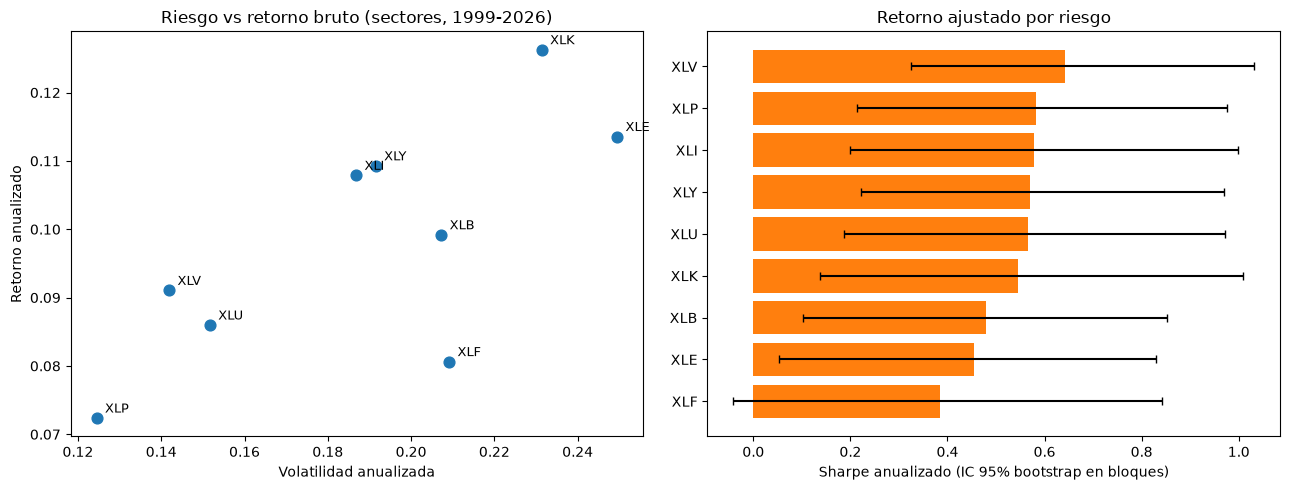

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(sector_tbl["vol_anual"], sector_tbl["ret_anual"], s=60, color="#1f77b4")
for tk, row in sector_tbl.iterrows():
    ax.annotate(tk, (row["vol_anual"], row["ret_anual"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("Volatilidad anualizada")
ax.set_ylabel("Retorno anualizado")
ax.set_title("Riesgo vs retorno bruto (sectores, 1999-2026)")

ax = axes[1]
ordered = sector_tbl.sort_values("sharpe")
err = np.array([ordered["sharpe"] - ordered["sharpe_ci_lo"],
                ordered["sharpe_ci_hi"] - ordered["sharpe"]])
ax.barh(ordered.index, ordered["sharpe"], xerr=err, color="#ff7f0e", capsize=3)
ax.set_xlabel("Sharpe anualizado (IC 95% bootstrap en bloques)")
ax.set_title("Retorno ajustado por riesgo")
plt.tight_layout()
plt.show()

### Contraste de H1

In [5]:
rho_sh, p_sh = stats.spearmanr(sector_tbl["vol_anual"], sector_tbl["sharpe"])
rho_ret, p_ret = stats.spearmanr(sector_tbl["vol_anual"], sector_tbl["ret_anual"])
print(f"Spearman volatilidad vs Sharpe:  rho = {rho_sh:.3f}, p = {p_sh:.3f}")
print(f"Spearman volatilidad vs retorno: rho = {rho_ret:.3f}, p = {p_ret:.3f}")

Spearman volatilidad vs Sharpe:  rho = -0.850, p = 0.004
Spearman volatilidad vs retorno: rho = 0.667, p = 0.050


**Lectura.** La volatilidad se asocia POSITIVAMENTE con el retorno bruto
(rho = 0.67, p = 0.05) pero NEGATIVAMENTE con el Sharpe (rho = -0.85, p = 0.004):
los sectores volátiles pagan algo más de retorno, pero mucho menos de lo que
cobran en riesgo. Salud (XLV) y consumo básico (XLP), los sectores defensivos,
lideran en Sharpe; financieras (XLF) y energía (XLE), los más volátiles, quedan
últimos.

## Robustez por subperiodos

In [6]:
def rho_subperiod(df):
    vol = df.std(ddof=1) * np.sqrt(12)
    sh = df.mean() / df.std(ddof=1) * np.sqrt(12)
    rho, p = stats.spearmanr(vol, sh)
    return rho, p, len(df)

subs = {"1999-2008": sec[sec.index < "2009"],
        "2009-2026": sec[sec.index >= "2009"],
        "pre-2020": sec[sec.index < "2020"],
        "2020-2026": sec[sec.index >= "2020"]}
rob = pd.DataFrame(
    [{"periodo": k, "rho": r, "p": p, "meses": n}
     for k, (r, p, n) in ((k, rho_subperiod(v)) for k, v in subs.items())]
).set_index("periodo")
rob.round(3)

,rho,p,meses
periodo,,,
1999-2008,-0.083,0.831,120
2009-2026,-0.683,0.042,211
pre-2020,-0.917,0.001,252
2020-2026,-0.167,0.668,79


**Lectura de robustez.** La correlación negativa es fuerte y significativa en las
ventanas largas (pre-2020: rho = -0.92, p = 0.001) y se atenúa en subperiodos
cortos (1999-2008 y 2020-2026 no significativos, con solo 9 sectores el poder
estadístico de ventanas cortas es bajo). Lo esencial para H1: **en ningún
subperiodo la relación es positiva**. No hay evidencia de que pagar más
volatilidad sectorial haya comprado mejor retorno ajustado en ningún régimen.

## Discusión y limitaciones

- Con 9 sectores, el contraste tiene pocos grados de libertad; por eso se usa
  Spearman y se reporta la dirección en subperiodos en lugar de fiarlo todo a un
  p-value.
- El resultado es coherente con la literatura de la anomalía de baja volatilidad
  (Baker, Bradley y Wurgler 2011), no un descubrimiento aislado de esta muestra.
- Sesgo de supervivencia del universo (RQ0): afecta niveles, no debería invertir
  el ordenamiento relativo entre sectores.
- Sharpe asume simetría; el Sortino de la tabla maestra apunta en la misma
  dirección.

## Conclusión ejecutiva

Entre 1999 y 2026, los sectores más volátiles del S&P 500 pagaron más retorno
bruto pero claramente menos retorno por unidad de riesgo: la correlación entre
volatilidad y Sharpe es -0.85 (p = 0.004) y no es positiva en ningún subperiodo.
H1 se sostiene: el riesgo sectorial extra no se compensa en términos ajustados.
Para una cartera de largo plazo, los sectores defensivos (salud, consumo básico)
ofrecieron el mejor pago por riesgo asumido.

In [7]:
out = Path.cwd().parent / "docs" / "resultados"
out.mkdir(parents=True, exist_ok=True)
lines = [
    "# RQ1. Riesgo vs retorno ajustado",
    "",
    "**Hipótesis H1:** la volatilidad sectorial no predice mayor Sharpe. **Veredicto: CONFIRMADA.**",
    "",
    f"- Spearman vol vs Sharpe (9 sectores, 1999-2026): rho = {rho_sh:.3f}, p = {p_sh:.3f}",
    f"- Spearman vol vs retorno bruto: rho = {rho_ret:.3f}, p = {p_ret:.3f}",
    "- En ningún subperiodo (1999-2008, 2009-2026, pre-2020, 2020-2026) la relación vol-Sharpe es positiva.",
    f"- Mejor Sharpe: {sector_tbl.index[0]} ({sector_tbl['sharpe'].iloc[0]:.2f}); peor: {sector_tbl.index[-1]} ({sector_tbl['sharpe'].iloc[-1]:.2f}).",
    "",
    "Caveats: 9 observaciones sectoriales; sesgo de supervivencia del universo; coherente con la anomalía de baja volatilidad.",
]
(out / "rq1.md").write_text("\n".join(lines), encoding="utf-8")
print("escrito docs/resultados/rq1.md")

escrito docs/resultados/rq1.md
